### Import all the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from greedy_auto_time_start_1 import Point, Route

### Import of functions

In [6]:
import greedy_auto_time_start_1 as auto_alg
import greedy_time_simulate_1 as sim_alg
from build_matrices import build_matrices
from k_medoids_2 import find_optimal_n_clusters_kmedoids

In [7]:
OSM_URL = "https://router.project-osrm.org"
OSM_MODE = "driving"
BLOCK_SIZE = 25
CREW_MEMBERS = 3
MAX_WORK_HOURS = 12

### Import the data

In [8]:
depots = pd.read_csv('synthetic_data_kyiv_varash/general.csv')

In [9]:
kyiv = depots[depots['city_name'] == 'Kyiv'].iloc[0]
kyiv_depot = Point("DEPOT", kyiv['depot_lan'], kyiv['depot_lot'], "DEPOT")
varash = depots[depots['city_name'] == 'Varash'].iloc[0]
varash_depot = Point("DEPOT", varash['depot_lan'], varash['depot_lot'], "DEPOT")

In [10]:
depots_simple = pd.read_csv('synthetic_data_ternopil_dubno/general.csv')

In [11]:
ternopil = depots_simple[depots_simple['city_name'] == 'Ternopil'].iloc[0]
ternopil_depot = Point("DEPOT", ternopil['depot_lan'], ternopil['depot_lot'], "DEPOT")
dubno = depots_simple[depots_simple['city_name'] == 'Dubno'].iloc[0]
dubno_depot = Point("DEPOT", dubno['depot_lan'], dubno['depot_lot'], "DEPOT")

In [12]:
kyiv_small = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_15.csv')
kyiv_small_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_03.csv')
kyiv_meduim_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_22.csv')
kyiv_meduim_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_11.csv')
kyiv_meduim_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_05.csv')
kyiv_meduim_4 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_12.csv')
kyiv_meduim_5 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_25.csv')
kyiv_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_02.csv')
kyiv_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_23.csv')
kyiv_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_19.csv')
varash_small = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_15.csv')
varash_small_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_23.csv')
varash_medium_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_10.csv')
varash_medium_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_21.csv')
varash_medium_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_09.csv')
varash_medium_4 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_24.csv')
varash_medium_5 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_12.csv')
varash_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_06.csv')
varash_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_02.csv')
varash_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_25.csv')
ternopil_small = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_07.csv')
ternopil_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_25.csv')
ternopil_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_22.csv')
ternopil_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_14.csv')
ternopil_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_23.csv')
ternopil_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_24.csv')
ternopil_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_13.csv')
ternopil_groos = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_01.csv')
ternopil_groos_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_02.csv')
ternopil_groos_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_15.csv')
dubno_small = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_01.csv')
dubno_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_21.csv')
dubno_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_22.csv')
dubno_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_09.csv')
dubno_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_17.csv')
dubno_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_16.csv')
dubno_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_14.csv')
dubno_gross = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_12.csv')
dubno_gross_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_11.csv')
dubno_gross_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_07.csv')

In [13]:
def format_points(df):
    '''
    function to convert the data into Point class objects
    '''
    df = df.copy()
    df["point_id"] = df["point_id"].astype(str)
    points = []

    for _, row in df.iterrows():
        tw_start = str(row["tw_start"]).strip() if pd.notna(row["tw_start"]) else None
        tw_end = str(row["tw_end"]).strip() if pd.notna(row["tw_end"]) else None

        point_obj = Point(
            str(row["point_id"]),
            row["lan"],
            row["lot"],
            row["point_type"],
            tw_start,
            tw_end
        )

        points.append(point_obj)

    return points

In [14]:
kyiv_s_p = format_points(kyiv_small)
kyiv_s_1_p = format_points(kyiv_small_1)
kyiv_m_1_p = format_points(kyiv_meduim_1)
kyiv_m_2_p = format_points(kyiv_meduim_2)
kyiv_m_3_p = format_points(kyiv_meduim_3)
kyiv_m_4_p = format_points(kyiv_meduim_4)
kyiv_m_5_p = format_points(kyiv_meduim_5)
kyiv_g_1_p = format_points(kyiv_gross_1)
kyiv_g_2_p = format_points(kyiv_gross_2)
kyiv_g_3_p = format_points(kyiv_gross_3)
varash_s_p = format_points(varash_small)
varash_s_1_p = format_points(varash_small_1)
varash_m_1_p = format_points(varash_medium_1)
varash_m_2_p = format_points(varash_medium_2)
varash_m_3_p = format_points(varash_medium_3)
varash_m_4_p = format_points(varash_medium_4)
varash_m_5_p = format_points(varash_medium_5)
varash_g_1_p = format_points(varash_gross_1)
varash_g_2_p = format_points(varash_gross_2)
varash_g_3_p = format_points(varash_gross_3)
ternopil_s_p = format_points(ternopil_small)
ternopil_s_1_p = format_points(ternopil_small_1)
ternopil_m_1_p = format_points(ternopil_medium_1)
ternopil_m_2_p = format_points(ternopil_medium_2)
ternopil_m_3_p = format_points(ternopil_medium_3)
ternopil_m_4_p = format_points(ternopil_medium_4)
ternopil_m_5_p = format_points(ternopil_medium_5)
ternopil_g_p= format_points(ternopil_groos)
ternopil_g_2_p = format_points(ternopil_groos_2)
ternopil_g_3_p= format_points(ternopil_groos_3)
dubno_s_p = format_points(dubno_small)
dubno_s_1_p = format_points(dubno_small_1)
dubno_m_1_p = format_points(dubno_medium_1)
dubno_m_2_p = format_points(dubno_medium_2)
dubno_m_3_p = format_points(dubno_medium_3)
dubno_m_4_p = format_points(dubno_medium_4)
dubno_m_5_p = format_points(dubno_medium_5)
dubno_g_p = format_points(dubno_gross)
dubno_g_2_p = format_points(dubno_gross_2)
dubno_g_3_p = format_points(dubno_gross_3)

In [15]:
def set_params(crew, crew_members, max_hours_work):
    result = dict()
    result['max_crews'] = crew
    result['max_workers'] =  crew*crew_members
    result['workers_per_crew'] =  crew_members
    result['max_route_duration_min'] = max_hours_work * 60
    return result

In [16]:
params_varash = set_params(varash['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_kyiv = set_params(kyiv['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_ternopil = set_params(ternopil['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_dubno = set_params(dubno['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)

In [17]:
cases = [
        {
            "name": "Kyiv_small",
            "depo": kyiv_depot,
            "stops": kyiv_s_p,
            "params": params_kyiv
        },
        {
            "name": "Kyiv_small_1",
            "depo": kyiv_depot,
            "stops": kyiv_s_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_1",
            "depo": kyiv_depot,
            "stops": kyiv_m_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_2",
            "depo": kyiv_depot,
            "stops": kyiv_m_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_3",
            "depo": kyiv_depot,
            "stops": kyiv_m_3_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_4",
            "depo": kyiv_depot,
            "stops": kyiv_m_4_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_5",
            "depo": kyiv_depot,
            "stops": kyiv_m_5_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_1",
            "depo": kyiv_depot,
            "stops": kyiv_g_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_2",
            "depo": kyiv_depot,
            "stops": kyiv_g_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_3",
            "depo": kyiv_depot,
            "stops": kyiv_g_3_p,
            "params": params_kyiv
        },
        {
            "name": "Varash_small",
            "depo": varash_depot,
            "stops": varash_s_p,
            "params": params_varash
        },
        {
            "name": "Varash_small_1",
            "depo": varash_depot,
            "stops": varash_s_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_1",
            "depo": varash_depot,
            "stops": varash_m_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_2",
            "depo": varash_depot,
            "stops": varash_m_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_3",
            "depo": varash_depot,
            "stops": varash_m_3_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_4",
            "depo": varash_depot,
            "stops": varash_m_4_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_5",
            "depo": varash_depot,
            "stops": varash_m_5_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_1",
            "depo": varash_depot,
            "stops": varash_g_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_2",
            "depo": varash_depot,
            "stops": varash_g_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_3",
            "depo": varash_depot,
            "stops": varash_g_3_p,
            "params": params_varash
        }
]

In [18]:
cases_simple = [
        {
            "name": "ternopil_small",
            "depo": ternopil_depot,
            "stops": ternopil_s_p,
            "params": params_ternopil
        },
        {
            "name": "ternopil_small_1",
            "depo": ternopil_depot,
            "stops": ternopil_s_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_1",
            "depo": ternopil_depot,
            "stops": ternopil_m_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_2",
            "depo": ternopil_depot,
            "stops": ternopil_m_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_3",
            "depo": ternopil_depot,
            "stops": ternopil_m_3_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_4",
            "depo": ternopil_depot,
            "stops": ternopil_m_4_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_5",
            "depo": ternopil_depot,
            "stops": ternopil_m_5_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_1",
            "depo": ternopil_depot,
            "stops": ternopil_g_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_2",
            "depo": ternopil_depot,
            "stops": ternopil_g_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_3",
            "depo": ternopil_depot,
            "stops": ternopil_g_3_p,
            "params": params_ternopil
        },
        {
            "name": "dubno_small",
            "depo": dubno_depot,
            "stops": dubno_s_p,
            "params": params_dubno
        },
        {
            "name": "dubno_small_1",
            "depo": dubno_depot,
            "stops": dubno_s_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_1",
            "depo": dubno_depot,
            "stops": dubno_m_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_2",
            "depo": dubno_depot,
            "stops": dubno_m_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_3",
            "depo": dubno_depot,
            "stops": dubno_m_3_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_4",
            "depo": dubno_depot,
            "stops": dubno_m_4_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_5",
            "depo": dubno_depot,
            "stops": dubno_m_5_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_1",
            "depo": dubno_depot,
            "stops": dubno_g_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_2",
            "depo": dubno_depot,
            "stops": dubno_g_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_3",
            "depo": dubno_depot,
            "stops": dubno_g_3_p,
            "params": params_dubno
        }
]

### Run the clasterization

In [19]:
fixed_seed = 42
best_iter_num = 10

In [20]:
def run_clusterization(cases, function, fixed_seed, iter_num, extra_kwargs=None):
    all_results = []
    
    for case in cases:
        name = case["name"]
        current_cache = f"cache_routes/cache_{name}.json"

        coords = [(case["depo"].lat, case["depo"].lon)] + [
            (s.lat, s.lon) for s in case["stops"]
        ]

        dist_km, time_min = build_matrices(
            coords=coords,
            cache_path=current_cache,
            name=name,
            block_size=25,
            osm_url=OSM_URL,
            osm_mode=OSM_MODE
        )

        build_routes_kwargs = {
            "max_crews": case["params"]["max_crews"],
            "max_workers": case["params"]["max_workers"],
            "workers_per_crew": case["params"]["workers_per_crew"],
            "max_route_duration_min": case["params"]["max_route_duration_min"],
        }

        if extra_kwargs is not None:
            build_routes_kwargs.update(extra_kwargs)

        result = find_optimal_n_clusters_kmedoids(
            day_stops=case["stops"],
            depo=case["depo"],
            dist_km=dist_km,
            time_min=time_min,
            max_crews=case["params"]["max_crews"],
            build_routes_ag=function,
            build_routes_kwargs=build_routes_kwargs,
            random_state=fixed_seed,
            max_iter=iter_num
        )

        case_result = {
            "case_name": name,
            "day_stops": case["stops"],
            "depo": case["depo"],
            "params": case["params"],
            "dist_km": dist_km,
            "time_min": time_min,
            "cluster_result": result,
            "routes": result["routes"],
            "summary": result["summary"],
            "labels": result["labels"],
            "medoid_indices": result["medoid_indices"],
            "cluster_details": result["cluster_details"],
        }

        all_results.append(case_result)

    return all_results

In [21]:
clust_data_original_math = run_clusterization(cases, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_original_sim = run_clusterization(cases, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

In [33]:
clust_data_simple_math = run_clusterization(cases_simple, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_simple_sim = run_clusterization(cases_simple, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

### Test VNS parameters

In [ ]:
from vns_3 import GlobalVNS, InfeasibleError

In [ ]:
def run_vns_parameter_testing(
    clustered_cases,
    route_cls,
    max_iterations_grid,
    local_search_max_iter_grid,
    seeds,
    k_max=5):

    results = []
    for case in clustered_cases:
        case_name = case["case_name"]

        for seed, max_iterations, local_search_max_iter in product(
            seeds, max_iterations_grid, local_search_max_iter_grid
        ):
            vns = GlobalVNS(
                day_stops=case["day_stops"],
                depo=case["depo"],
                dist_km=case["dist_km"],
                time_min=case["time_min"],
                max_route_duration_min=case["params"]["max_route_duration_min"],
                random_state=seed
            )

            k_history = []
            original_shake = vns.shake

            def tracked_shake(solution, k):
                k_history.append(k)
                return original_shake(solution, k)

            vns.shake = tracked_shake

            try:
                best_routes, best_value = vns.main_vns(
                    initial_routes=case["routes"],
                    route_cls=route_cls,
                    max_iterations=max_iterations,
                    k_max=k_max,
                    local_search_max_iter=local_search_max_iter
                )

                total_duration, total_distance = best_value

                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iterations,
                    "local_search_max_iter": local_search_max_iter,
                    "k_max": k_max,
                    "total_duration": total_duration,
                    "total_distance": total_distance,
                    "max_k_reached": max(k_history) if k_history else None,
                    "mean_k_reached": sum(k_history) / len(k_history) if k_history else None,
                    "n_shake_calls": len(k_history),
                    "status": "ok",
                    "best_routes": best_routes
                })

            except InfeasibleError as e:
                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iterations,
                    "local_search_max_iter": local_search_max_iter,
                    "k_max": k_max,
                    "total_duration": float("inf"),
                    "total_distance": float("inf"),
                    "max_k_reached": max(k_history) if k_history else None,
                    "mean_k_reached": sum(k_history) / len(k_history) if k_history else None,
                    "n_shake_calls": len(k_history),
                    "status": f"infeasible: {str(e)}",
                    "best_routes": None
                })

            finally:
                vns.shake = original_shake

    return pd.DataFrame(results)

In [76]:
max_iterations_grid = [1000, 2000, 5000, 10000]
local_search_max_iter_grid = [20, 50, 100]
seeds = [5, 20, 42, 100]

In [77]:
vns_test_math_original = run_vns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations_grid=max_iterations_grid,
    local_search_max_iter_grid=local_search_max_iter_grid,
    seeds=seeds,
    k_max=5
)

In [82]:
vns_test_sim_original = run_vns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations_grid=max_iterations_grid,
    local_search_max_iter_grid=local_search_max_iter_grid,
    seeds=seeds,
    k_max=5
)

In [83]:
vns_test_math_simple = run_vns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations_grid=max_iterations_grid,
    local_search_max_iter_grid=local_search_max_iter_grid,
    seeds=seeds,
    k_max=5
)

In [107]:
vns_test_sim_simple = run_vns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations_grid=max_iterations_grid,
    local_search_max_iter_grid=local_search_max_iter_grid,
    seeds=seeds,
    k_max=5
)

In [108]:
all_vns_df = pd.concat([
    vns_test_math_original.assign(Method="Math_Start"),
    vns_test_sim_original.assign(Method="Sim_Start"),
    vns_test_math_simple.assign(Method="Math_Start"),
    vns_test_sim_simple.assign(Method="Sim_Start"),
], ignore_index=True)

In [109]:
all_vns_df

,case_name,seed,max_iterations,local_search_max_iter,k_max,total_duration,total_distance,max_k_reached,mean_k_reached,n_shake_calls,status,best_routes,Method
0,Kyiv_small,5,1000,20,5,9232.730000,3090.5599,5,2.882453,5853,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
1,Kyiv_small,5,1000,50,5,9232.730000,3090.5599,5,2.882453,5853,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
2,Kyiv_small,5,1000,100,5,9232.730000,3090.5599,5,2.882453,5853,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
3,Kyiv_small,5,2000,20,5,8985.885000,2736.9243,5,2.894843,11402,ok,"[Route(crew_id=2, stop_sequence=['DEPOT', 'KYI...",Math_Start
4,Kyiv_small,5,2000,50,5,8985.885000,2736.9243,5,2.894843,11402,ok,"[Route(crew_id=2, stop_sequence=['DEPOT', 'KYI...",Math_Start
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,dubno_gross_3,100,5000,50,5,588.473333,104.3488,5,2.994037,25321,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
3836,dubno_gross_3,100,5000,100,5,588.473333,104.3488,5,2.994037,25321,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
3837,dubno_gross_3,100,10000,20,5,588.473333,104.3488,5,2.996999,50321,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
3838,dubno_gross_3,100,10000,50,5,588.473333,104.3488,5,2.996999,50321,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start


In [110]:
per_dataset_summary = (
    all_vns_df
    .groupby(
        ["case_name", "Method", "max_iterations", "local_search_max_iter"],
        as_index=False
    )
    .agg(
        mean_duration=("total_duration", "mean"),
        median_duration=("total_duration", "median"),
        std_duration=("total_duration", "std"),
        mean_distance=("total_distance", "mean"),
        median_distance=("total_distance", "median"),
        std_distance=("total_distance", "std"),
        mean_max_k_reached=("max_k_reached", "mean"),
        mean_k_reached=("mean_k_reached", "mean"),
        mean_n_shake_calls=("n_shake_calls", "mean"),
    )
)

In [111]:
per_dataset_summary

,case_name,Method,max_iterations,local_search_max_iter,mean_duration,median_duration,std_duration,mean_distance,median_distance,std_distance,mean_max_k_reached,mean_k_reached,mean_n_shake_calls
0,Kyiv_gross_1,Math_Start,1000,20,12625.552917,12603.390833,248.933599,4418.264200,4354.66565,500.648291,5.0,2.878129,5792.50
1,Kyiv_gross_1,Math_Start,1000,50,12625.552917,12603.390833,248.933599,4418.264200,4354.66565,500.648291,5.0,2.878129,5792.50
2,Kyiv_gross_1,Math_Start,1000,100,12625.552917,12603.390833,248.933599,4418.264200,4354.66565,500.648291,5.0,2.878129,5792.50
3,Kyiv_gross_1,Math_Start,2000,20,11914.843750,11856.372500,186.756437,4858.579975,4852.99335,246.188023,5.0,2.872292,11653.50
4,Kyiv_gross_1,Math_Start,2000,50,11914.843750,11856.372500,186.756437,4858.579975,4852.99335,246.188023,5.0,2.872292,11653.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,ternopil_small_1,Sim_Start,5000,50,1740.573750,1676.273333,133.839783,343.649625,345.05335,5.980415,5.0,2.977200,25655.25
956,ternopil_small_1,Sim_Start,5000,100,1740.573750,1676.273333,133.839783,343.649625,345.05335,5.980415,5.0,2.977200,25655.25
957,ternopil_small_1,Sim_Start,10000,20,1727.528750,1657.496667,142.471958,330.417875,330.68925,10.866686,5.0,2.986524,50756.00
958,ternopil_small_1,Sim_Start,10000,50,1727.528750,1657.496667,142.471958,330.417875,330.68925,10.866686,5.0,2.986524,50756.00


In [112]:
global_summary = (
    per_dataset_summary
    .groupby(
        ["Method", "max_iterations", "local_search_max_iter"],
        as_index=False
    )
    .agg(
        mean_duration=("mean_duration", "mean"),
        std_duration_across_cases=("mean_duration", "std"),
        mean_distance=("mean_distance", "mean"),
        std_distance_across_cases=("mean_distance", "std"),
        mean_max_k_reached=("mean_max_k_reached", "mean"),
        mean_k_reached=("mean_k_reached", "mean"),
        mean_n_shake_calls=("mean_n_shake_calls", "mean"),
    )
)

In [113]:
global_summary

,Method,max_iterations,local_search_max_iter,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_max_k_reached,mean_k_reached,mean_n_shake_calls
0,Math_Start,1000,20,3982.666500,4370.809066,1151.710825,1416.058356,5.0,2.937909,5400.13750
1,Math_Start,1000,50,3982.666500,4370.809066,1151.710825,1416.058356,5.0,2.937909,5400.13750
2,Math_Start,1000,100,3982.666500,4370.809066,1151.710825,1416.058356,5.0,2.937909,5400.13750
3,Math_Start,2000,20,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
4,Math_Start,2000,50,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
5,Math_Start,2000,100,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
6,Math_Start,5000,20,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
7,Math_Start,5000,50,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
8,Math_Start,5000,100,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
9,Math_Start,10000,20,3573.577094,3770.937712,1005.030445,1274.278701,5.0,2.976886,51386.25000


In [114]:
top_math = (
    global_summary[
        (global_summary["Method"] == "Math_Start")
    ]
    .sort_values(by=["mean_duration", "mean_distance"], ascending=[True, True])
)

In [115]:
top_math

,Method,max_iterations,local_search_max_iter,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_max_k_reached,mean_k_reached,mean_n_shake_calls
9,Math_Start,10000,20,3573.577094,3770.937712,1005.030445,1274.278701,5.0,2.976886,51386.25000
10,Math_Start,10000,50,3573.577094,3770.937712,1005.030445,1274.278701,5.0,2.976886,51386.25000
11,Math_Start,10000,100,3573.577094,3770.937712,1005.030445,1274.278701,5.0,2.976886,51386.25000
6,Math_Start,5000,20,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
7,Math_Start,5000,50,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
8,Math_Start,5000,100,3683.445573,3944.210166,1068.192069,1354.146067,5.0,2.966408,26029.66875
3,Math_Start,2000,20,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
4,Math_Start,2000,50,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
5,Math_Start,2000,100,3849.336208,4192.267920,1171.662595,1497.515575,5.0,2.950427,10627.60625
0,Math_Start,1000,20,3982.666500,4370.809066,1151.710825,1416.058356,5.0,2.937909,5400.13750


In [116]:
top_sim = (
    global_summary[
        (global_summary["Method"] == "Sim_Start")
    ]
    .sort_values(by=["mean_duration", "mean_distance"], ascending=[True, True])
)

In [117]:
top_sim

,Method,max_iterations,local_search_max_iter,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_max_k_reached,mean_k_reached,mean_n_shake_calls
21,Sim_Start,10000,20,3075.041146,3078.683954,911.374167,1110.993349,5.0,2.980796,51063.78750
22,Sim_Start,10000,50,3075.041146,3078.683954,911.374167,1110.993349,5.0,2.980796,51063.78750
23,Sim_Start,10000,100,3075.041146,3078.683954,911.374167,1110.993349,5.0,2.980796,51063.78750
18,Sim_Start,5000,20,3123.956729,3154.438799,961.304661,1178.046451,5.0,2.970544,25828.74375
19,Sim_Start,5000,50,3123.956729,3154.438799,961.304661,1178.046451,5.0,2.970544,25828.74375
20,Sim_Start,5000,100,3123.956729,3154.438799,961.304661,1178.046451,5.0,2.970544,25828.74375
15,Sim_Start,2000,20,3197.712083,3263.908534,1034.902536,1261.274968,5.0,2.952665,10553.15000
16,Sim_Start,2000,50,3197.712083,3263.908534,1034.902536,1261.274968,5.0,2.952665,10553.15000
17,Sim_Start,2000,100,3197.712083,3263.908534,1034.902536,1261.274968,5.0,2.952665,10553.15000
12,Sim_Start,1000,20,3261.714292,3355.279168,1072.765242,1279.717483,5.0,2.935863,5388.11250


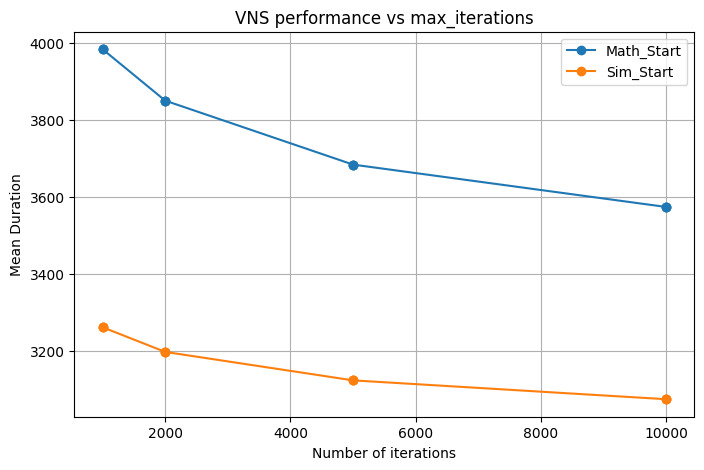

In [118]:
plot_math = global_summary[global_summary["Method"] == "Math_Start"]
plot_sim = global_summary[global_summary["Method"] == "Sim_Start"]

plt.figure(figsize=(8, 5))
plt.plot(plot_math["max_iterations"], plot_math["mean_duration"], marker='o', label="Math_Start")
plt.plot(plot_sim["max_iterations"], plot_sim["mean_duration"], marker='o', label="Sim_Start")

plt.xlabel("Number of iterations")
plt.ylabel("Mean Duration")
plt.title("VNS performance vs max_iterations")
plt.legend()
plt.grid()

plt.show()

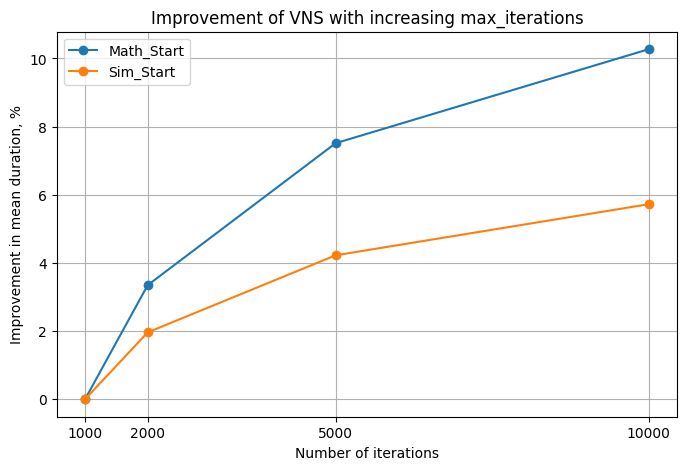

In [119]:
plot_df = global_summary.copy()
plot_df = plot_df[plot_df["local_search_max_iter"] == 20].copy()

plot_df["baseline_duration"] = plot_df.groupby("Method")["mean_duration"].transform("first")
plot_df["improvement_pct"] = (
    (plot_df["baseline_duration"] - plot_df["mean_duration"]) / plot_df["baseline_duration"] * 100
)

plt.figure(figsize=(8, 5))

for method in plot_df["Method"].unique():
    method_df = plot_df[plot_df["Method"] == method].sort_values("max_iterations")
    plt.plot(
        method_df["max_iterations"],
        method_df["improvement_pct"],
        marker="o",
        label=method
    )

plt.xticks([1000, 2000, 5000, 10000], [1000, 2000, 5000, 10000])
plt.xlabel("Number of iterations")
plt.ylabel("Improvement in mean duration, %")
plt.title("Improvement of VNS with increasing max_iterations")
plt.legend()
plt.grid()
plt.show()

### The best params

In [ ]:
the_best_local_search_max_iter = 20
the_best_max_iterations = 5000